In [1]:
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from collections import defaultdict
import csv

# -------------------------------------------------
# Device
# -------------------------------------------------
print(f"Number of GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------
batch_size    = 32
num_epochs    = 10
learning_rate = 0.001
img_rows, img_cols = 128, 128
n_folds = 5

# -------------------------------------------------
# Paths
# -------------------------------------------------
control_folder  = r'C:\Users\RTX2080Ti\Desktop\Dyslexia DL\FCM\control'
dyslexia_folder = r'C:\Users\RTX2080Ti\Desktop\Dyslexia DL\FCM\dyslexia'

# -------------------------------------------------
# Load data
# -------------------------------------------------
def load_images_from_folder(folder, label):
    data = []
    for imagePath in paths.list_images(folder):
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (img_cols, img_rows))
        data.append((image, label))
    return data

control_data  = load_images_from_folder(control_folder, 0)
dyslexia_data = load_images_from_folder(dyslexia_folder, 1)

data = control_data + dyslexia_data
np.random.seed(42)
np.random.shuffle(data)

X = np.array([d[0] for d in data], dtype=np.float32)
y = np.array([d[1] for d in data], dtype=np.float32)
X /= 255.0

print(f"Total samples: {len(X)}  (Control: {(y==0).sum()}, Dyslexia: {(y==1).sum()})")

# -------------------------------------------------
# CNN Model
# -------------------------------------------------
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * (img_rows // 4) * (img_cols // 4), 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# -------------------------------------------------
# Hold-out test set (15%) + 5-Fold CV on the rest
# -------------------------------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"Train+Val: {len(X_trainval)} | Test: {len(X_test)}")

# Convert to tensors
X_trainval_t = torch.tensor(X_trainval).permute(0, 3, 1, 2).float()
y_trainval_t = torch.tensor(y_trainval).float().unsqueeze(1)

X_test_t = torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_test_t = torch.tensor(y_test).float().unsqueeze(1)

# -------------------------------------------------
# 5-Fold Stratified Cross-Validation
# -------------------------------------------------
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

fold_results = []
best_val_acc = 0.0
best_model_state = None

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold}/{n_folds}")
    print(f"{'='*60}")

    X_tr = X_trainval_t[train_idx]
    y_tr = y_trainval_t[train_idx]
    X_va = X_trainval_t[val_idx]
    y_va = y_trainval_t[val_idx]

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

    model = CNNModel().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        # ---- train ----
        model.train()
        train_loss = 0.0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * data.size(0)

        # ---- validate ----
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output, target).item() * data.size(0)
                pred = (output > 0.5).float()
                correct += pred.eq(target).sum().item()

        train_loss /= len(train_loader.dataset)
        val_loss   /= len(val_loader.dataset)
        accuracy   = correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {accuracy:.4f}")

    fold_results.append({"fold": fold, "val_loss": val_loss, "val_acc": accuracy})

    if accuracy > best_val_acc:
        best_val_acc = accuracy
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# -------------------------------------------------
# CV Summary
# -------------------------------------------------
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("="*60)
val_accs   = [r["val_acc"] for r in fold_results]
val_losses = [r["val_loss"] for r in fold_results]
print(f"Mean Val Accuracy : {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Mean Val Loss     : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
for r in fold_results:
    print(f"  Fold {r['fold']}: Acc={r['val_acc']:.4f}  Loss={r['val_loss']:.4f}")

# -------------------------------------------------
# Final model on ALL train+val data
# -------------------------------------------------
print("\nRetraining final model on full Train+Val set …")
final_loader = DataLoader(TensorDataset(X_trainval_t, y_trainval_t),
                          batch_size=batch_size, shuffle=True)

model = CNNModel().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data, target in final_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    print(f"Final Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(final_loader.dataset):.4f}")

torch.save(model.state_dict(), "cnn_pytorch_model_5fold.pth")
print("Final model saved → cnn_pytorch_model_5fold.pth")

# -------------------------------------------------
# Evaluate on the held-out test set
# -------------------------------------------------
model.eval()
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=50, shuffle=False)

test_loss = 0.0
correct = 0
total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item() * data.size(0)
        pred = (output > 0.5).float()
        correct += pred.eq(target).sum().item()
        total += target.size(0)
        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

test_loss /= total
test_acc = correct / total
print(f"\nHeld-out Test Loss: {test_loss:.4f}")
print(f"Held-out Test Accuracy: {test_acc*100:.2f}%")

# For Grad-CAM compatibility
X_test = X_test_t
y_test = y_test_t.squeeze()

Number of GPUs available: 2
GPU 0: NVIDIA GeForce RTX 2080 Ti
GPU 1: NVIDIA GeForce RTX 2080 Ti
Using device: cuda:1
Total samples: 7982  (Control: 4566, Dyslexia: 3416)
Train+Val: 6784 | Test: 1198

FOLD 1/5
Epoch  1/10 | Train Loss: 0.6698 | Val Loss: 0.6075 | Val Acc: 0.7119
Epoch  2/10 | Train Loss: 0.3404 | Val Loss: 0.1011 | Val Acc: 0.9661
Epoch  3/10 | Train Loss: 0.0817 | Val Loss: 0.0455 | Val Acc: 0.9816
Epoch  4/10 | Train Loss: 0.0362 | Val Loss: 0.0058 | Val Acc: 0.9985
Epoch  5/10 | Train Loss: 0.0279 | Val Loss: 0.0153 | Val Acc: 0.9934
Epoch  6/10 | Train Loss: 0.0171 | Val Loss: 0.0045 | Val Acc: 0.9985
Epoch  7/10 | Train Loss: 0.0149 | Val Loss: 0.0035 | Val Acc: 0.9978
Epoch  8/10 | Train Loss: 0.0160 | Val Loss: 0.0123 | Val Acc: 0.9978
Epoch  9/10 | Train Loss: 0.0158 | Val Loss: 0.0080 | Val Acc: 0.9963
Epoch 10/10 | Train Loss: 0.0139 | Val Loss: 0.0042 | Val Acc: 0.9993

FOLD 2/5
Epoch  1/10 | Train Loss: 0.6643 | Val Loss: 0.4779 | Val Acc: 0.7929
Epoch  2/10

In [2]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

# Journal-quality defaults
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

HELD-OUT TEST SET PERFORMANCE
Accuracy      : 1.0000
Precision     : 1.0000
Recall        : 1.0000
F1-Score      : 1.0000
ROC-AUC       : 1.0000
PR-AUC        : 1.0000

Classification Report:
              precision    recall  f1-score   support

     Control       1.00      1.00      1.00       685
    Dyslexia       1.00      1.00      1.00       513

    accuracy                           1.00      1198
   macro avg       1.00      1.00      1.00      1198
weighted avg       1.00      1.00      1.00      1198



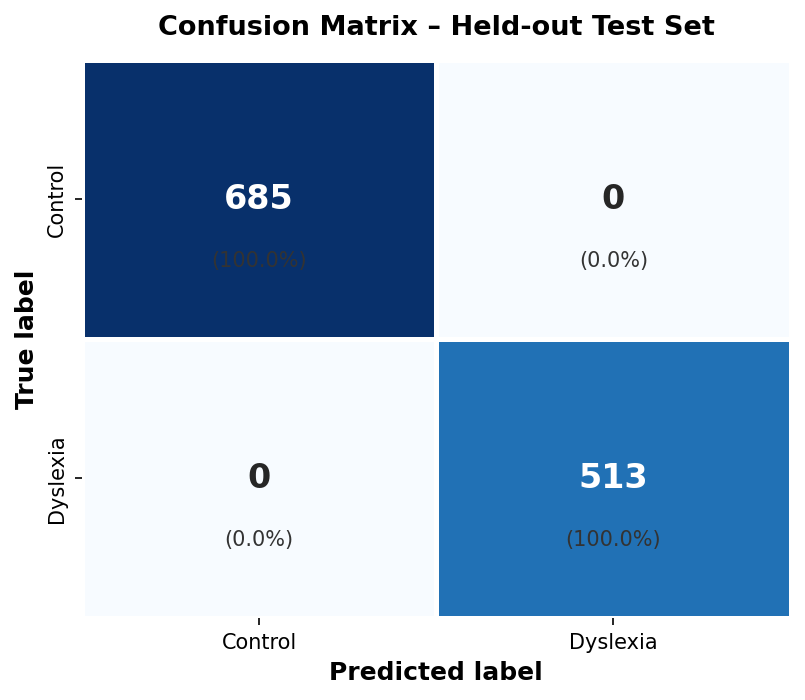

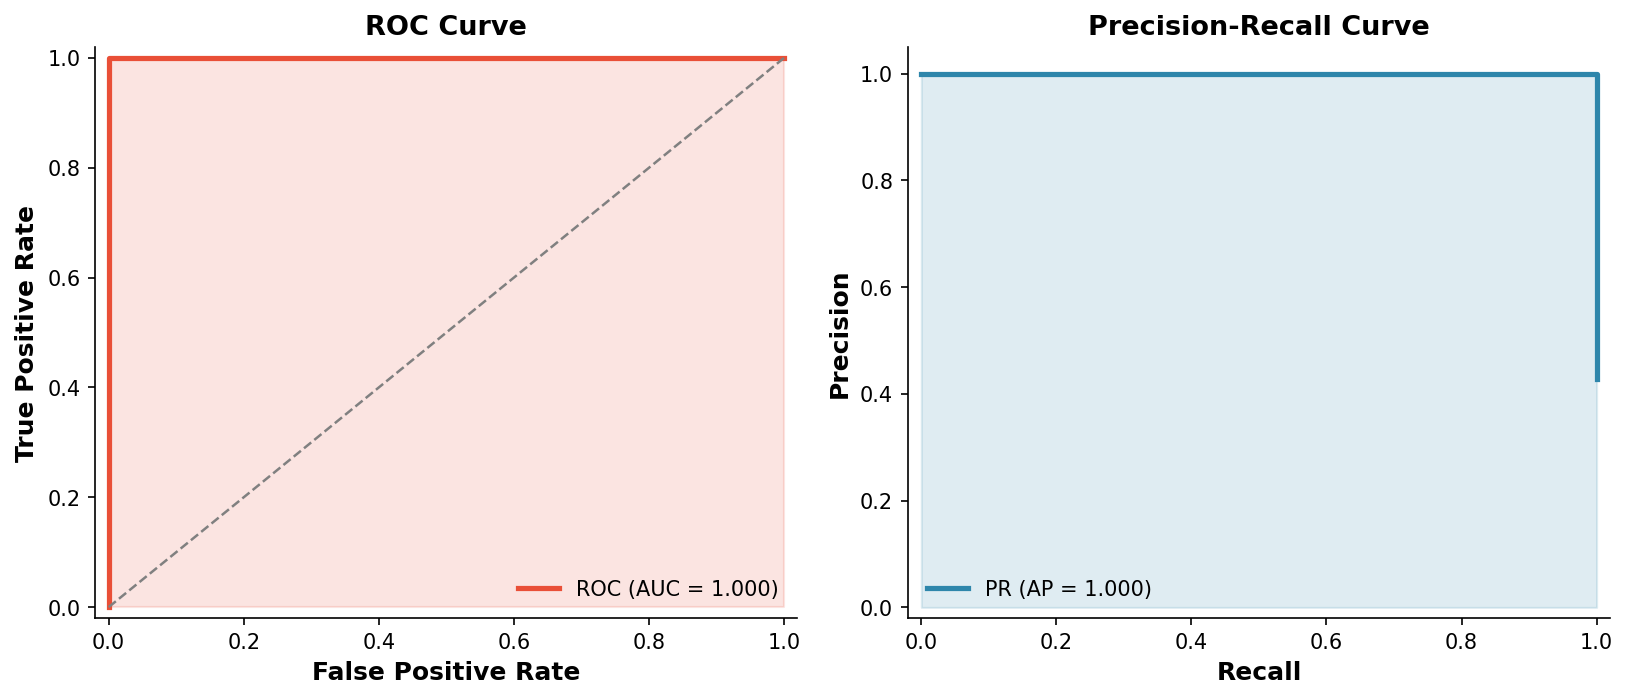

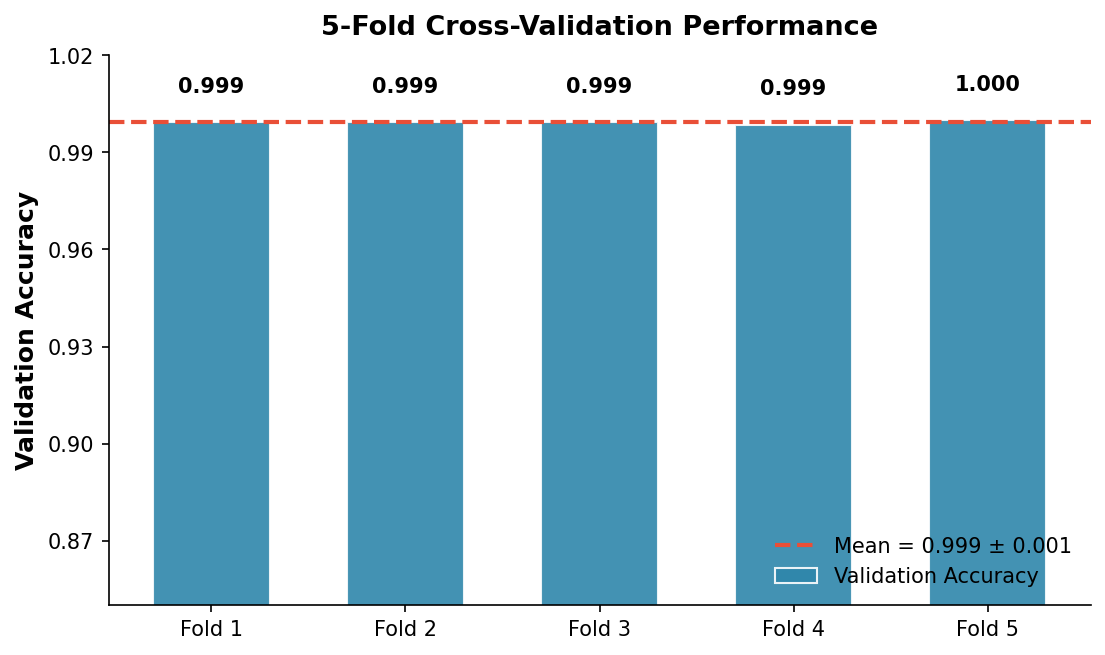

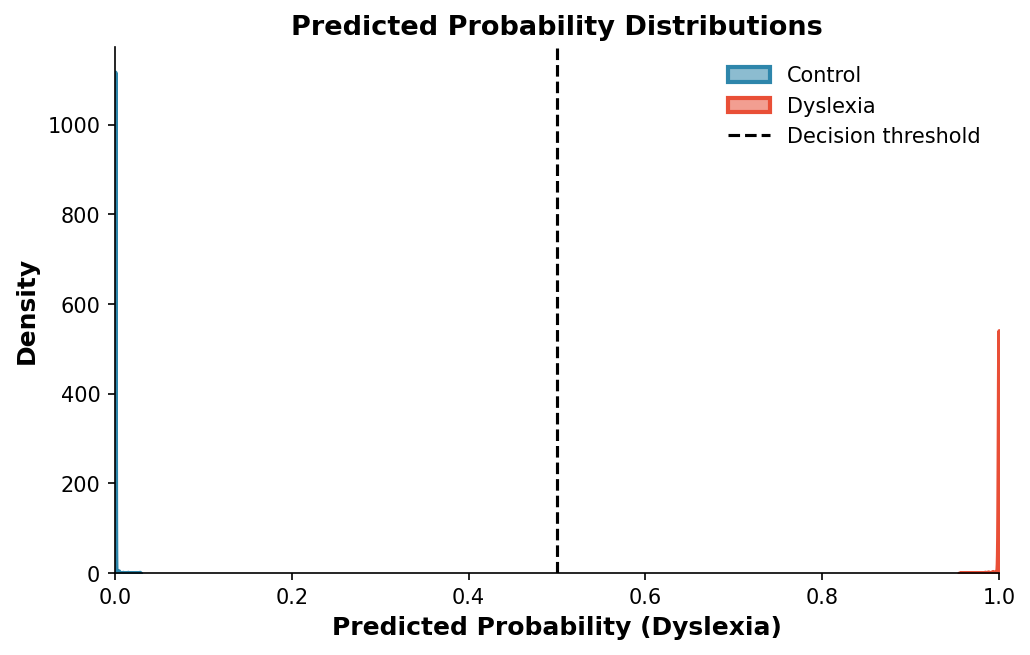

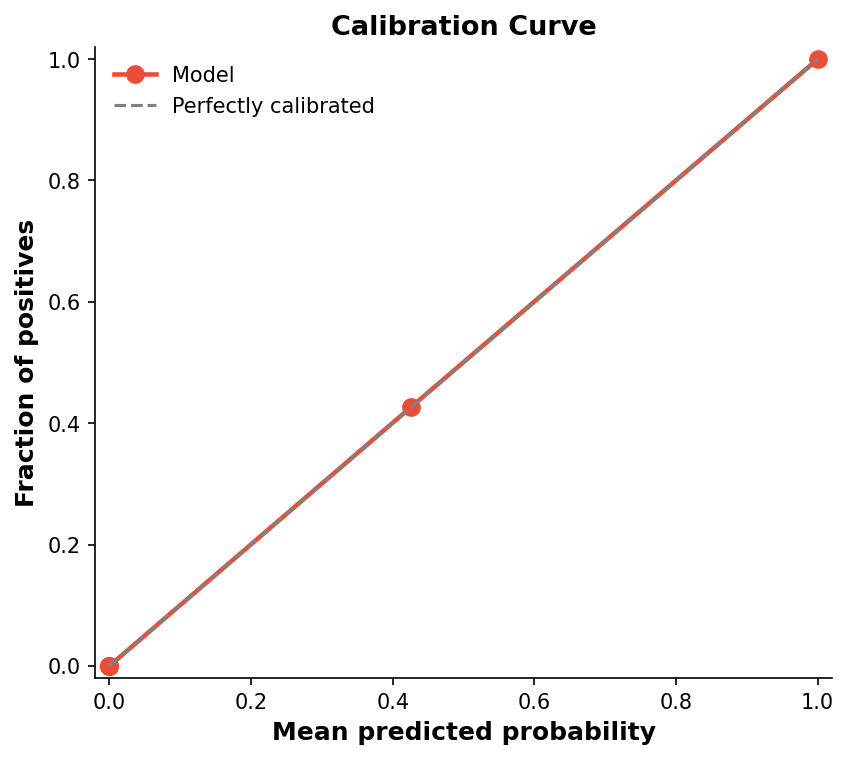

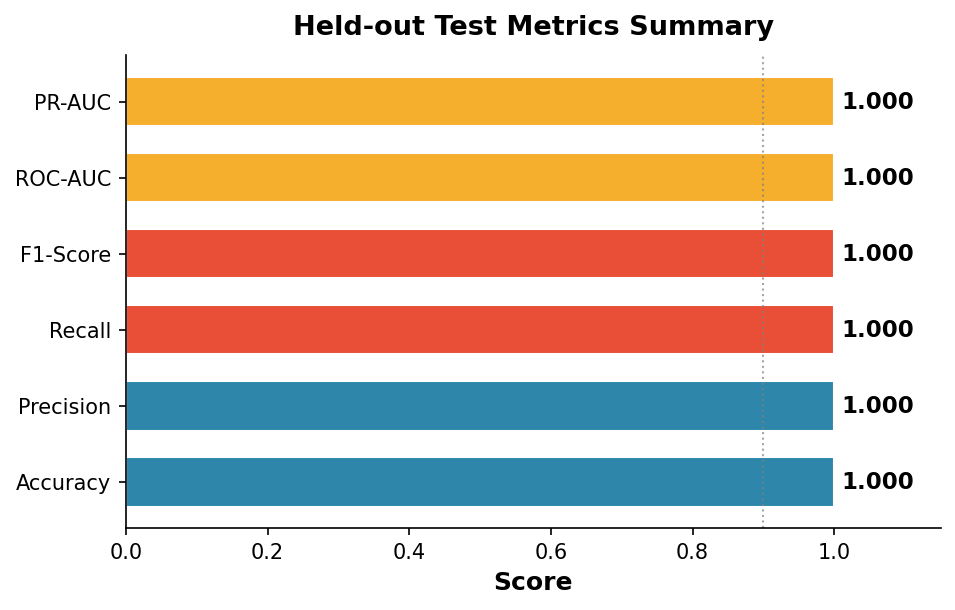


Saved → test_metrics_summary.csv
All figures saved as PNG (300 dpi) + PDF


In [3]:
# ============================================================
# EVALUATION & FIGURES
# ============================================================

model.eval()
y_true = []
y_prob = []
y_pred = []

with torch.no_grad():
    for data, target in DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64):
        data = data.to(device)
        output = model(data).cpu().numpy().ravel()
        y_prob.extend(output)
        y_pred.extend((output > 0.5).astype(int))
        y_true.extend(target.numpy().ravel().astype(int))

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.array(y_pred)

# -------------------------------------------------
# 1. Metrics summary
# -------------------------------------------------
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

print("="*55)
print("HELD-OUT TEST SET PERFORMANCE")
print("="*55)
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")
print(f"PR-AUC        : {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Control', 'Dyslexia']))

# -------------------------------------------------
# Color palette (color-blind friendly)
# -------------------------------------------------
colors = {
    'control': '#2E86AB',
    'dyslexia': '#E94F37',
    'accent': '#F6AE2D',
    'neutral': '#4A4A4A',
    'light': '#F5F5F5'
}

# ============================================================
# FIGURE 1 – Confusion Matrix
# ============================================================
fig, ax = plt.subplots(figsize=(5.5, 4.8))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Control', 'Dyslexia'],
            yticklabels=['Control', 'Dyslexia'],
            cbar=False, linewidths=1.5, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)

# Add percentages
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'({cm_norm[i,j]*100:.1f}%)',
                ha='center', va='center', fontsize=10, color='#333333')

ax.set_xlabel('Predicted label', fontweight='bold')
ax.set_ylabel('True label', fontweight='bold')
ax.set_title('Confusion Matrix – Held-out Test Set', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig1_confusion_matrix.png', dpi=300)
plt.savefig('fig1_confusion_matrix.pdf')
plt.show()

# ============================================================
# FIGURE 2 – ROC + Precision-Recall (side-by-side)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, color=colors['dyslexia'], lw=2.5,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], ls='--', color='grey', lw=1.2)
axes[0].fill_between(fpr, tpr, alpha=0.15, color=colors['dyslexia'])
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right', frameon=False)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# PR
precision, recall, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(recall, precision, color=colors['control'], lw=2.5,
             label=f'PR (AP = {pr_auc:.3f})')
axes[1].fill_between(recall, precision, alpha=0.15, color=colors['control'])
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='lower left', frameon=False)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.savefig('fig2_roc_pr_curves.png', dpi=300)
plt.savefig('fig2_roc_pr_curves.pdf')
plt.show()

# ============================================================
# FIGURE 3 – Cross-Validation Results (bar + error)
# ============================================================
fold_df = pd.DataFrame(fold_results)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

x = np.arange(len(fold_df))
bars = ax.bar(x, fold_df['val_acc'], color=colors['control'],
              edgecolor='white', width=0.6, alpha=0.9,
              label='Validation Accuracy')

# Mean line
mean_acc = fold_df['val_acc'].mean()
std_acc  = fold_df['val_acc'].std()
ax.axhline(mean_acc, color=colors['dyslexia'], ls='--', lw=2,
           label=f'Mean = {mean_acc:.3f} ± {std_acc:.3f}')

# Annotate bars
for bar, acc in zip(bars, fold_df['val_acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in fold_df['fold']])
ax.set_ylabel('Validation Accuracy', fontweight='bold')
ax.set_title('5-Fold Cross-Validation Performance', fontweight='bold', pad=10)
ax.set_ylim(0.85, 1.02)
ax.legend(frameon=False, loc='lower right')
ax.yaxis.set_major_locator(MaxNLocator(6))

plt.tight_layout()
plt.savefig('fig3_cv_results.png', dpi=300)
plt.savefig('fig3_cv_results.pdf')
plt.show()

# ============================================================
# FIGURE 4 – Probability distribution (class separation)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.kdeplot(y_prob[y_true == 0], fill=True, color=colors['control'],
            alpha=0.55, label='Control', linewidth=2, ax=ax)
sns.kdeplot(y_prob[y_true == 1], fill=True, color=colors['dyslexia'],
            alpha=0.55, label='Dyslexia', linewidth=2, ax=ax)

ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision threshold')
ax.set_xlabel('Predicted Probability (Dyslexia)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Predicted Probability Distributions', fontweight='bold')
ax.legend(frameon=False)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('fig4_prob_distributions.png', dpi=300)
plt.savefig('fig4_prob_distributions.pdf')
plt.show()

# ============================================================
# FIGURE 5 – Calibration curve
# ============================================================
fig, ax = plt.subplots(figsize=(5.8, 5.2))

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=8, strategy='quantile')

ax.plot(prob_pred, prob_true, 'o-', color=colors['dyslexia'], lw=2.2,
        markersize=8, label='Model')
ax.plot([0, 1], [0, 1], '--', color='grey', lw=1.5, label='Perfectly calibrated')

ax.set_xlabel('Mean predicted probability', fontweight='bold')
ax.set_ylabel('Fraction of positives', fontweight='bold')
ax.set_title('Calibration Curve', fontweight='bold')
ax.legend(frameon=False)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('fig5_calibration.png', dpi=300)
plt.savefig('fig5_calibration.pdf')
plt.show()

# ============================================================
# FIGURE 6 – Metrics radar / summary table figure
# ============================================================
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'PR-AUC': pr_auc
}

fig, ax = plt.subplots(figsize=(6.5, 4.2))
names = list(metrics.keys())
values = list(metrics.values())

bars = ax.barh(names, values, color=[colors['control'], colors['control'],
                                     colors['dyslexia'], colors['dyslexia'],
                                     colors['accent'], colors['accent']],
               edgecolor='white', height=0.65)

for bar, val in zip(bars, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Score', fontweight='bold')
ax.set_title('Held-out Test Metrics Summary', fontweight='bold', pad=10)
ax.axvline(0.9, color='grey', ls=':', lw=1, alpha=0.7)

plt.tight_layout()
plt.savefig('fig6_metrics_summary.png', dpi=300)
plt.savefig('fig6_metrics_summary.pdf')
plt.show()

print("\nSaved → test_metrics_summary.csv")
print("All figures saved as PNG (300 dpi) + PDF")

Correctly classified Control  : 685
Correctly classified Dyslexic : 513
Computing averaged Grad-CAM++ maps

Processing 100 Control samples …
  Control: 20/100 processed
  Control: 40/100 processed
  Control: 60/100 processed
  Control: 80/100 processed
  Control: 100/100 processed
  Control: finished (100 successful CAMs)

Processing 100 Dyslexic samples …
  Dyslexic: 20/100 processed
  Dyslexic: 40/100 processed
  Dyslexic: 60/100 processed
  Dyslexic: 80/100 processed
  Dyslexic: 100/100 processed
  Dyslexic: finished (100 successful CAMs)
Hooks removed.

Extracting discriminative channel pairs

Top 30 pairs — CONTROL
Rank   Ch_i     Ch_j     Mean CAM  
------------------------------------
1      E26      E57      0.8609
2      E27      E57      0.8219
3      E26      E56      0.8192
4      E35      E56      0.8059
5      E35      E57      0.8048
6      E27      E56      0.7809
7      E25      E57      0.7802
8      E26      E58      0.7710
9      E34      E57      0.7608
10     E36 

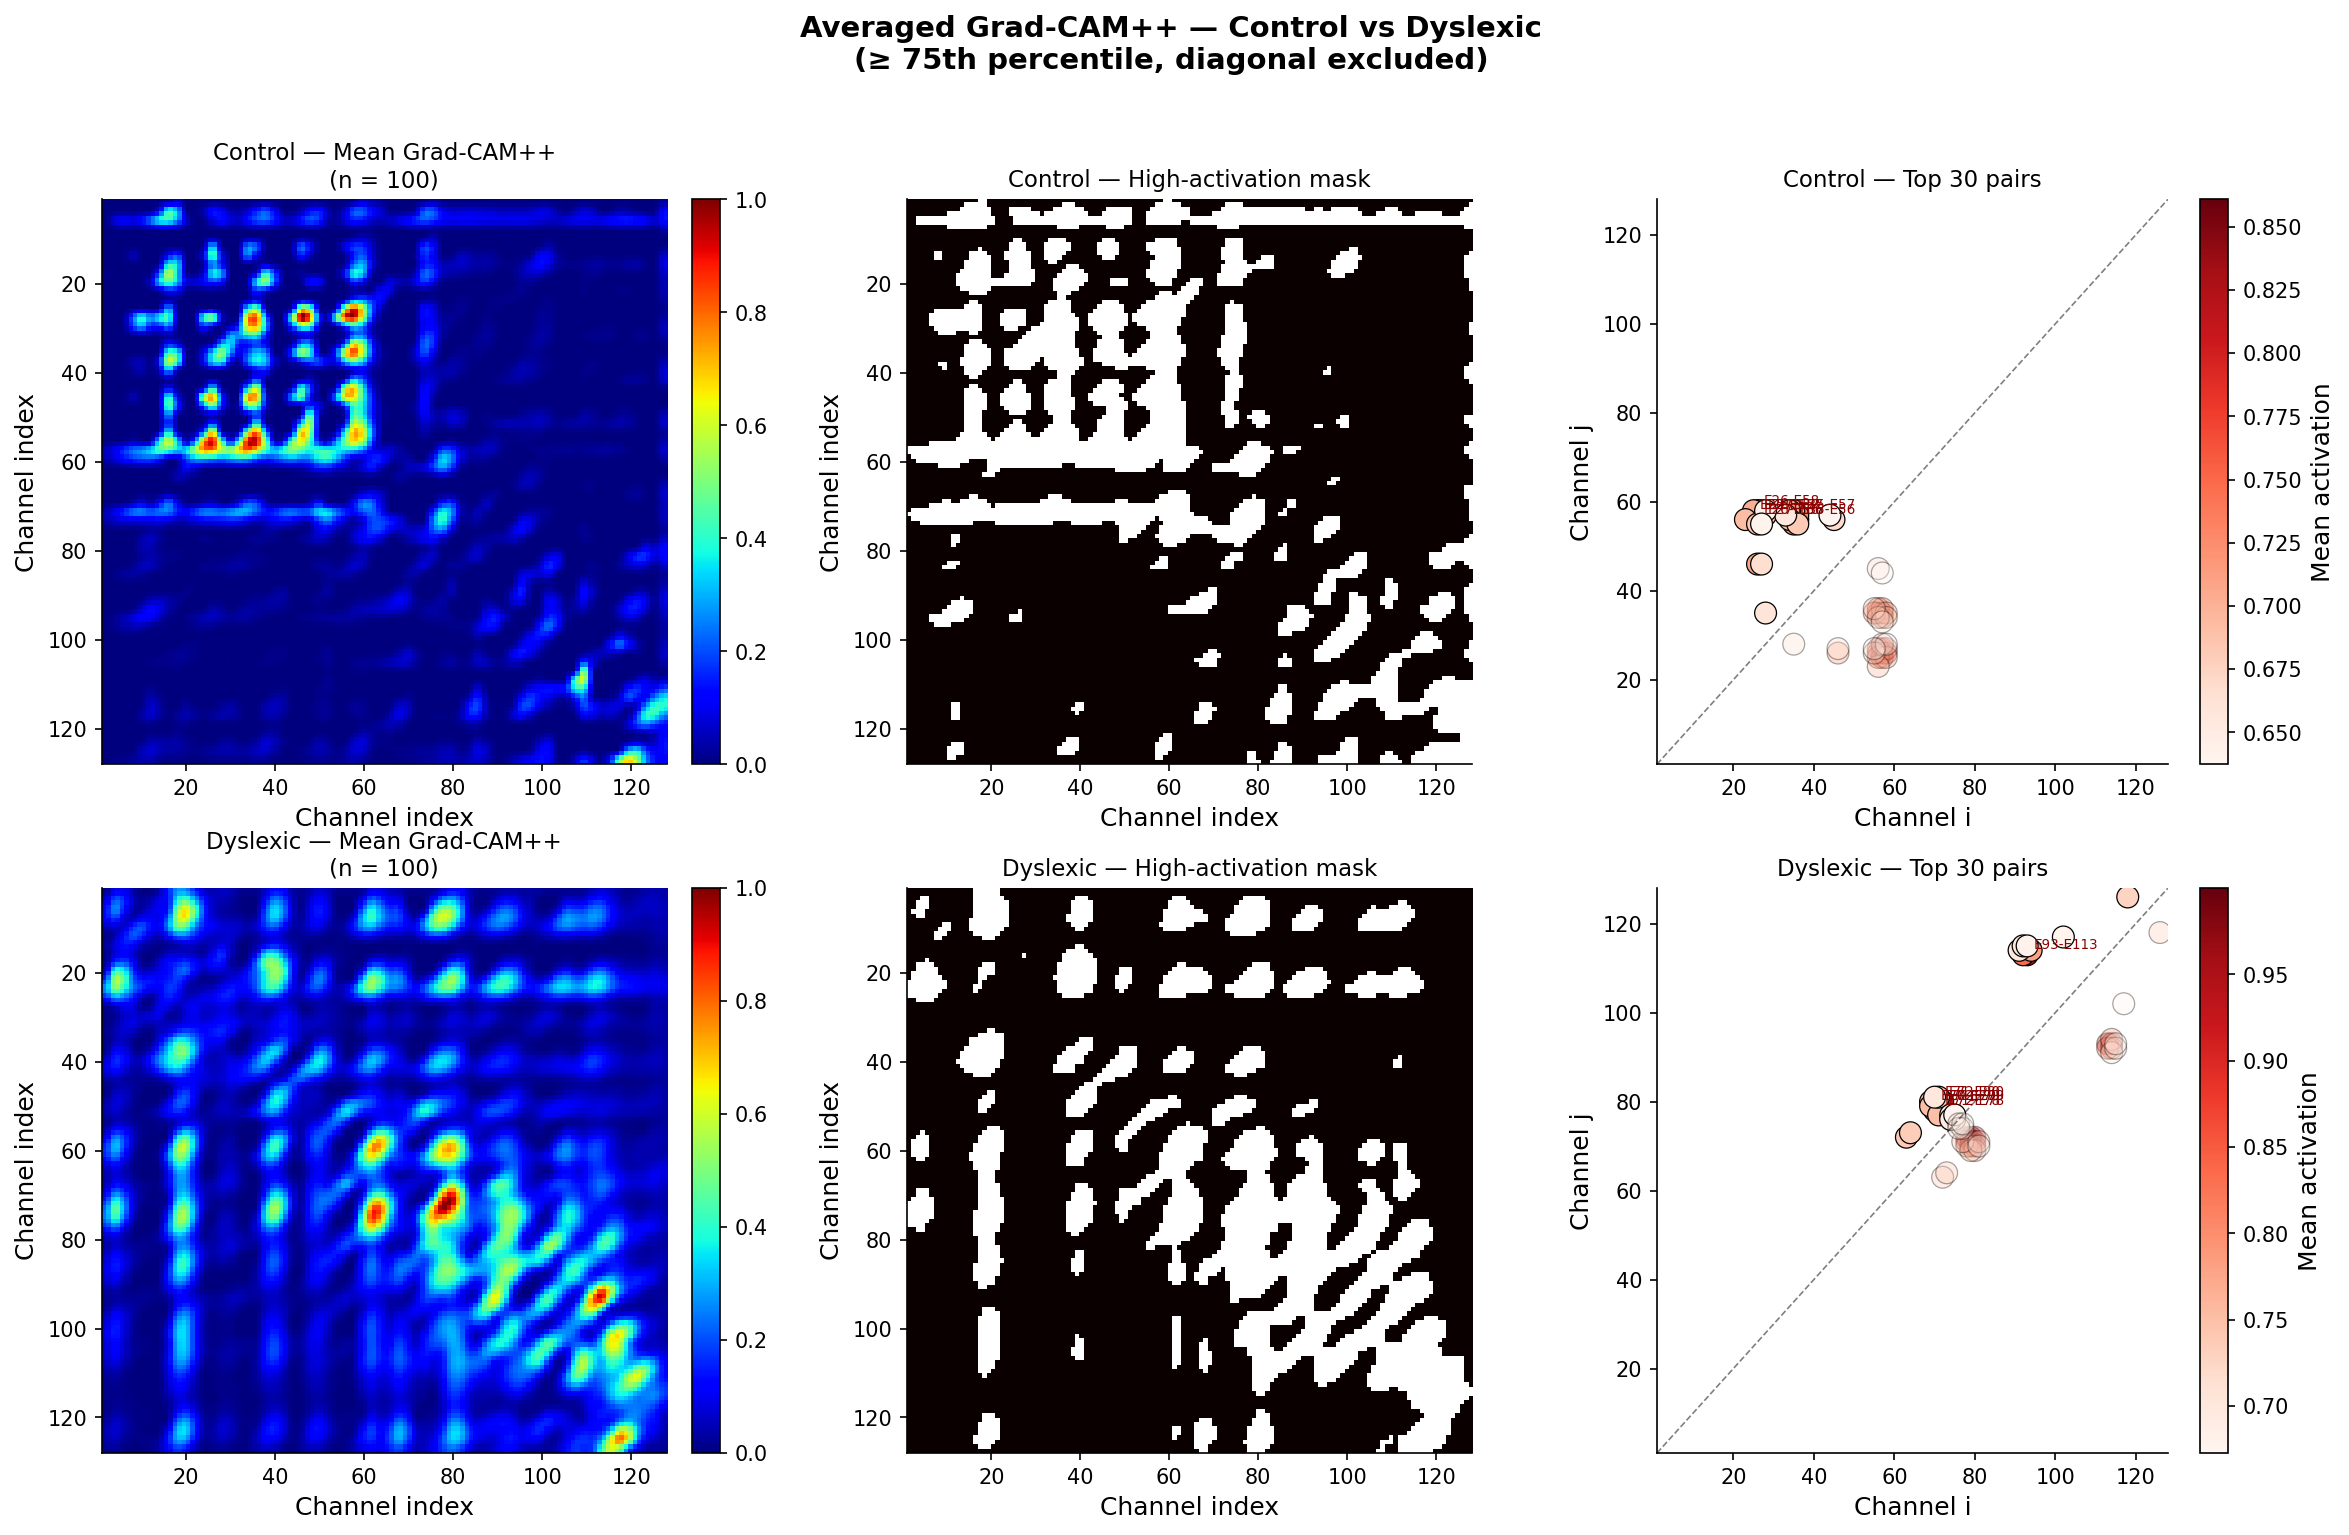

Saved → gradcam_averaged_channel_pairs.png / .pdf
Saved → channel_pairs_control.csv
Saved → channel_pairs_dyslexic.csv


In [4]:
# ============================================================
# Grad-CAM++ Analysis
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
from collections import defaultdict
import csv

# -------------------- Config --------------------
img_rows, img_cols = 128, 128
N_CHANNELS         = 128
TOP_N_PAIRS        = 30
CAM_THRESHOLD      = 0.75          # percentile
MAX_SAMPLES        = 100           # per class (for speed)

# -------------------- Find correctly classified samples --------------------
model.eval()
correct_control_idx  = []
correct_dyslexic_idx = []

with torch.no_grad():
    for i in range(len(X_test)):
        img = X_test[i].unsqueeze(0).to(device)          # (1, 3, H, W)
        label = y_test[i]
        
        # handle both tensor and float
        true_label = int(label.item() if torch.is_tensor(label) else label)
        
        out = model(img)
        pred = int(out.item() > 0.5)
        
        if pred == true_label == 0:
            correct_control_idx.append(i)
        elif pred == true_label == 1:
            correct_dyslexic_idx.append(i)

print(f"Correctly classified Control  : {len(correct_control_idx)}")
print(f"Correctly classified Dyslexic : {len(correct_dyslexic_idx)}")

if len(correct_control_idx) == 0 or len(correct_dyslexic_idx) == 0:
    raise ValueError("No correctly classified samples found for one of the classes. "
                     "Cannot compute class-specific Grad-CAM++.")

# -------------------- Grad-CAM++ class --------------------
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._fwd = target_layer.register_forward_hook(self._save_act)
        self._bwd = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor):
        """Returns CAM (H,W) in [0,1], pred_label, pred_prob."""
        input_tensor = input_tensor.to(device)
        self.model.zero_grad()
        
        output = self.model(input_tensor)          # (1, 1)
        pred_prob  = output.item()
        pred_label = int(pred_prob > 0.5)

        # Backward on the probability (works well for binary sigmoid)
        output.backward()

        A  = self.activations                      # (1, C, h, w)
        dS = self.gradients                        # (1, C, h, w)

        eps = 1e-7
        dS2 = dS ** 2
        dS3 = dS ** 3
        global_sum = A.sum(dim=(2, 3), keepdim=True)
        alpha = dS2 / (2.0 * dS2 + global_sum * dS3 + eps)
        weights = (alpha * F.relu(dS)).sum(dim=(2, 3))   # (1, C)

        cam = (weights[:, :, None, None] * A).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()

        # Normalize to [0, 1]
        c_min, c_max = cam.min(), cam.max()
        cam = (cam - c_min) / (c_max - c_min + eps)
        return cam, pred_label, pred_prob

    def remove_hooks(self):
        self._fwd.remove()
        self._bwd.remove()

# -------------------- Helper --------------------
def pixel_to_channel(r, c, img_h=img_rows, img_w=img_cols, n_ch=N_CHANNELS):
    ch_row = int(r / img_h * n_ch) + 1
    ch_col = int(c / img_w * n_ch) + 1
    return ch_row, ch_col

# -------------------- Accumulate CAMs --------------------
print("=" * 60)
print("Computing averaged Grad-CAM++ maps")
print("=" * 60)

gradcam_pp = GradCAMPlusPlus(model, target_layer=model.conv5)
model.eval()

np.random.seed(42)
ctrl_indices = np.random.choice(
    correct_control_idx,
    size=min(MAX_SAMPLES, len(correct_control_idx)),
    replace=False
)
dys_indices = np.random.choice(
    correct_dyslexic_idx,
    size=min(MAX_SAMPLES, len(correct_dyslexic_idx)),
    replace=False
)

def accumulate_cams(indices, class_name):
    cam_sum = np.zeros((img_rows, img_cols), dtype=np.float64)
    n_success = 0

    for i, idx in enumerate(indices):
        img_tensor = X_test[idx].unsqueeze(0).float()   # (1, 3, H, W)
        try:
            cam, _, _ = gradcam_pp.generate(img_tensor)
            cam_up = cv2.resize(cam, (img_cols, img_rows),
                                interpolation=cv2.INTER_LINEAR)
            cam_sum += cam_up
            n_success += 1
        except Exception as e:
            print(f"  [warn] sample {idx} failed: {e}")

        if (i + 1) % 20 == 0:
            print(f"  {class_name}: {i+1}/{len(indices)} processed")

    mean_cam = cam_sum / max(n_success, 1)
    mn, mx = mean_cam.min(), mean_cam.max()
    mean_cam = (mean_cam - mn) / (mx - mn + 1e-7)
    print(f"  {class_name}: finished ({n_success} successful CAMs)")
    return mean_cam

print(f"\nProcessing {len(ctrl_indices)} Control samples …")
mean_cam_ctrl = accumulate_cams(ctrl_indices, "Control")

print(f"\nProcessing {len(dys_indices)} Dyslexic samples …")
mean_cam_dys  = accumulate_cams(dys_indices, "Dyslexic")

gradcam_pp.remove_hooks()
print("Hooks removed.")

# -------------------- Extract channel pairs --------------------
print("\n" + "=" * 60)
print("Extracting discriminative channel pairs")
print("=" * 60)

def extract_channel_pairs(mean_cam, threshold_percentile=CAM_THRESHOLD*100, top_n=TOP_N_PAIRS):
    threshold = np.percentile(mean_cam, threshold_percentile)
    binary_mask = (mean_cam >= threshold).astype(np.uint8)

    pair_activation = defaultdict(list)
    ys, xs = np.where(binary_mask)

    for r, c in zip(ys, xs):
        ch_i, ch_j = pixel_to_channel(r, c)
        if ch_i == ch_j:
            continue
        key = (min(ch_i, ch_j), max(ch_i, ch_j))
        pair_activation[key].append(mean_cam[r, c])

    ranked = sorted(
        [(f"E{k[0]}", f"E{k[1]}", float(np.mean(v)))
         for k, v in pair_activation.items()],
        key=lambda x: x[2], reverse=True
    )
    return ranked[:top_n], binary_mask, threshold

ctrl_pairs, ctrl_mask, _ = extract_channel_pairs(mean_cam_ctrl)
dys_pairs,  dys_mask,  _ = extract_channel_pairs(mean_cam_dys)

def print_pairs(pairs, name):
    print(f"\nTop {len(pairs)} pairs — {name}")
    print(f"{'Rank':<6} {'Ch_i':<8} {'Ch_j':<8} {'Mean CAM':<10}")
    print("-" * 36)
    for rank, (ci, cj, act) in enumerate(pairs, 1):
        print(f"{rank:<6} {ci:<8} {cj:<8} {act:.4f}")

print_pairs(ctrl_pairs, "CONTROL")
print_pairs(dys_pairs,  "DYSLEXIC")

# Unique / shared pairs
ctrl_set = {(p[0], p[1]) for p in ctrl_pairs}
dys_set  = {(p[0], p[1]) for p in dys_pairs}
print(f"\nUnique to Control : {len(ctrl_set - dys_set)}")
print(f"Unique to Dyslexic: {len(dys_set - ctrl_set)}")
print(f"Shared pairs      : {len(ctrl_set & dys_set)}")

# -------------------- Visualization (Journal quality) --------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Averaged Grad-CAM++ — Control vs Dyslexic\n"
             f"(≥ {CAM_THRESHOLD*100:.0f}th percentile, diagonal excluded)",
             fontsize=14, fontweight="bold", y=1.02)

class_data = [
    ("Control",  mean_cam_ctrl, ctrl_mask, ctrl_pairs, len(ctrl_indices)),
    ("Dyslexic", mean_cam_dys,  dys_mask,  dys_pairs,  len(dys_indices)),
]

for row, (cname, mean_cam, mask, pairs, n_samp) in enumerate(class_data):
    # 1. Mean CAM
    ax = axes[row, 0]
    im = ax.imshow(mean_cam, cmap="jet", vmin=0, vmax=1,
                   extent=[1, N_CHANNELS, N_CHANNELS, 1])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{cname} — Mean Grad-CAM++\n(n = {n_samp})", fontsize=11)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")

    # 2. Thresholded mask
    ax = axes[row, 1]
    ax.imshow(mask, cmap="hot", vmin=0, vmax=1,
              extent=[1, N_CHANNELS, N_CHANNELS, 1])
    ax.set_title(f"{cname} — High-activation mask", fontsize=11)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")

    # 3. Top pairs scatter
    ax = axes[row, 2]
    if pairs:
        ci = [int(p[0][1:]) for p in pairs]
        cj = [int(p[1][1:]) for p in pairs]
        strengths = [p[2] for p in pairs]
        sc = ax.scatter(ci, cj, c=strengths, cmap="Reds", s=110,
                        edgecolors="k", linewidths=0.6,
                        vmin=min(strengths), vmax=max(strengths))
        ax.scatter(cj, ci, c=strengths, cmap="Reds", s=110,
                   edgecolors="k", linewidths=0.6, alpha=0.35,
                   vmin=min(strengths), vmax=max(strengths))
        plt.colorbar(sc, ax=ax, label="Mean activation")
        for p in pairs[:8]:
            ax.annotate(f"{p[0]}-{p[1]}", (int(p[0][1:]), int(p[1][1:])),
                        textcoords="offset points", xytext=(3, 3),
                        fontsize=6.5, color="darkred")
    ax.plot([1, N_CHANNELS], [1, N_CHANNELS], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(1, N_CHANNELS)
    ax.set_ylim(1, N_CHANNELS)
    ax.set_xlabel("Channel i")
    ax.set_ylabel("Channel j")
    ax.set_title(f"{cname} — Top {TOP_N_PAIRS} pairs", fontsize=11)

plt.tight_layout()
plt.savefig("gradcam_averaged_channel_pairs.png", dpi=300, bbox_inches="tight")
plt.savefig("gradcam_averaged_channel_pairs.pdf", bbox_inches="tight")
plt.show()
print("Saved → gradcam_averaged_channel_pairs.png / .pdf")

# -------------------- Export CSVs --------------------
for class_name, pairs in [("Control", ctrl_pairs), ("Dyslexic", dys_pairs)]:
    fname = f"channel_pairs_{class_name.lower()}.csv"
    with open(fname, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Rank", "Channel_i", "Channel_j", "Mean_CAM_Activation", "Class"])
        for rank, (ci, cj, act) in enumerate(pairs, 1):
            writer.writerow([rank, ci, cj, f"{act:.6f}", class_name])
    print(f"Saved → {fname}")

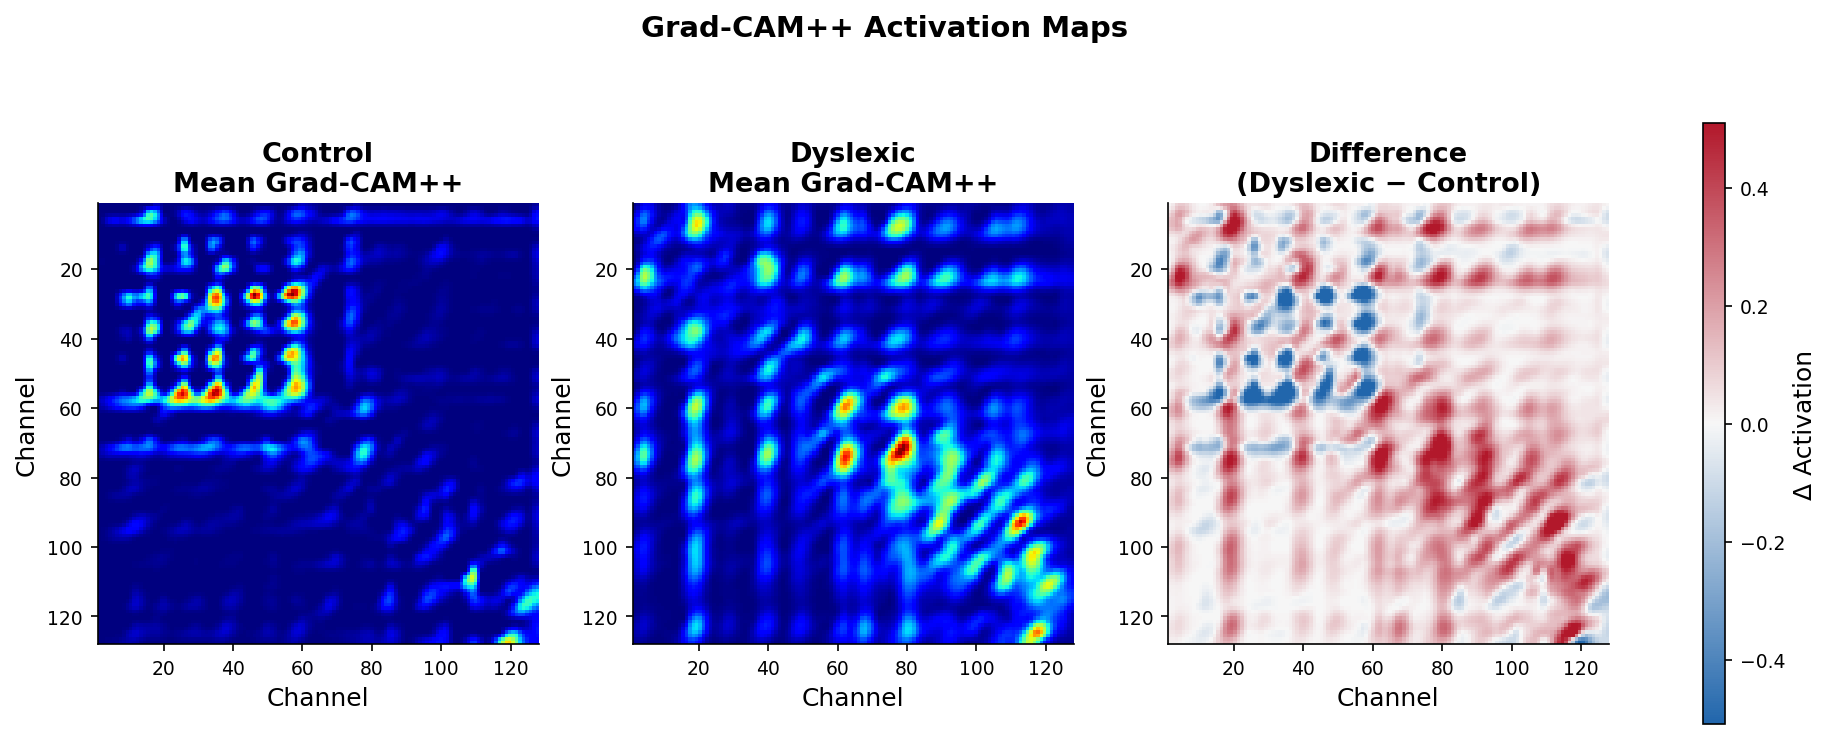

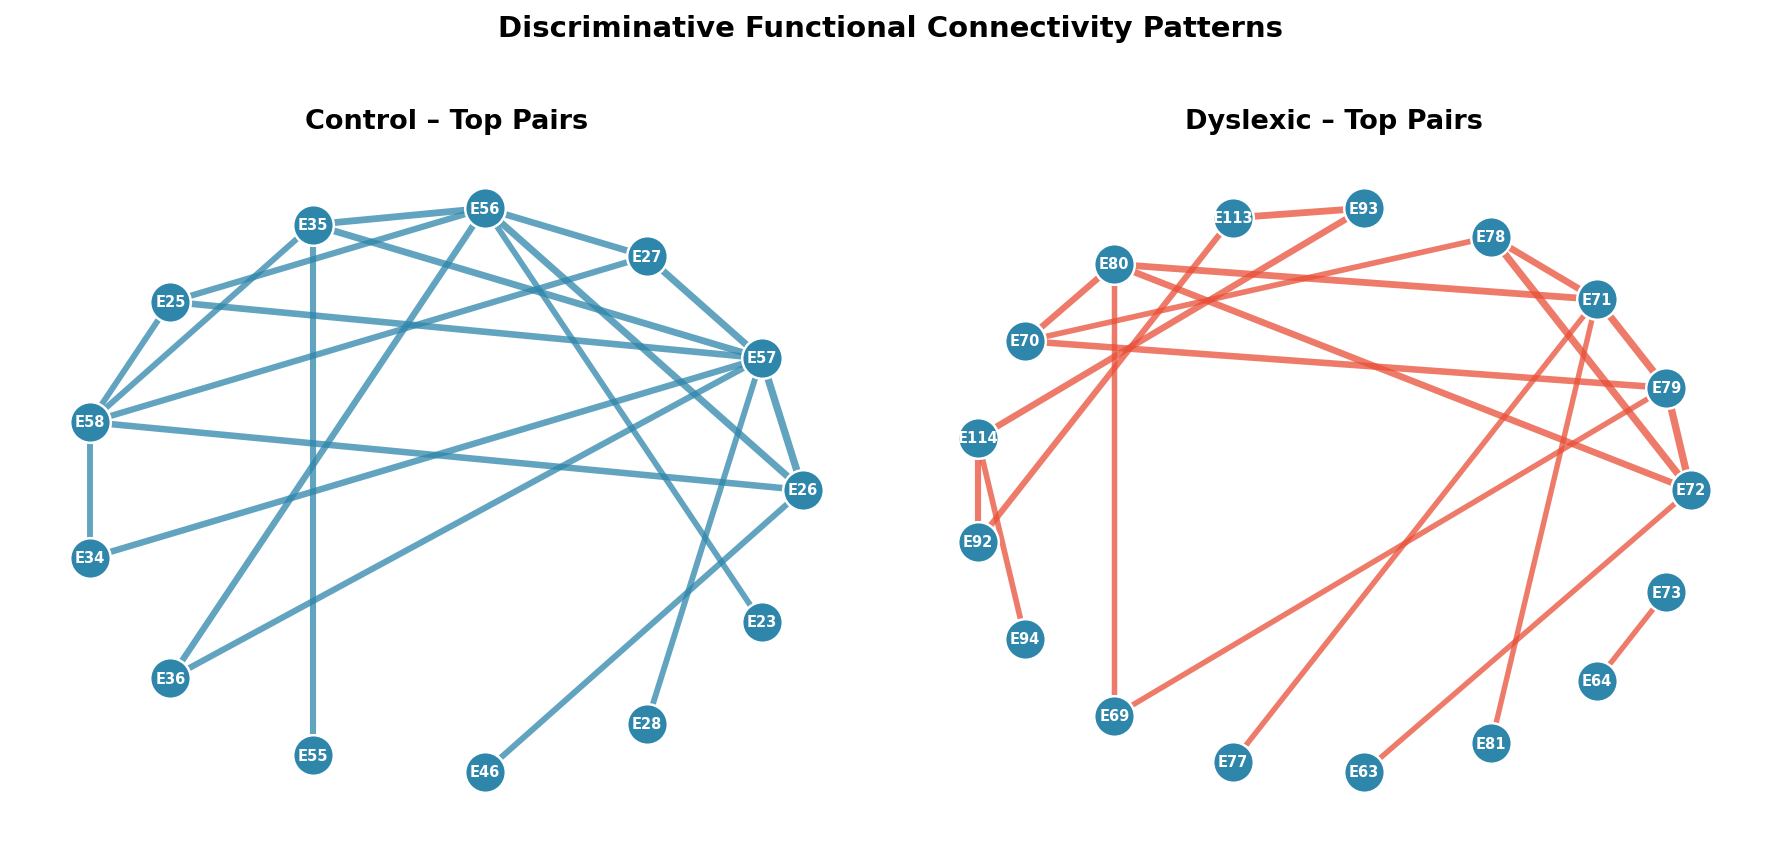

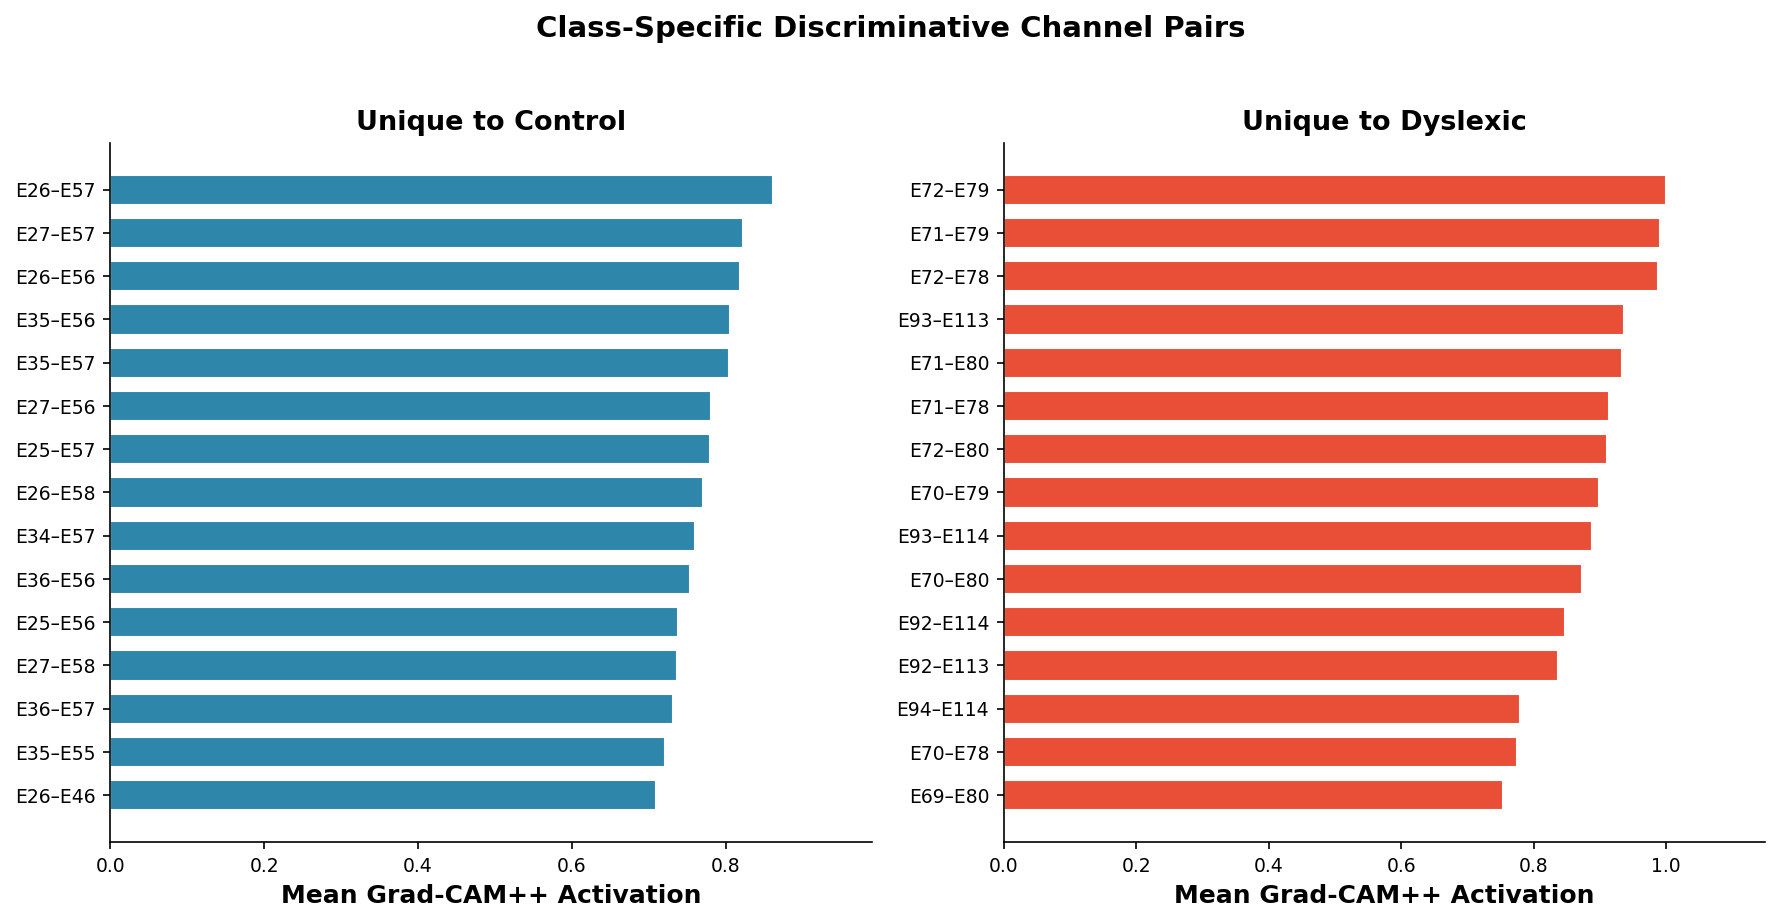

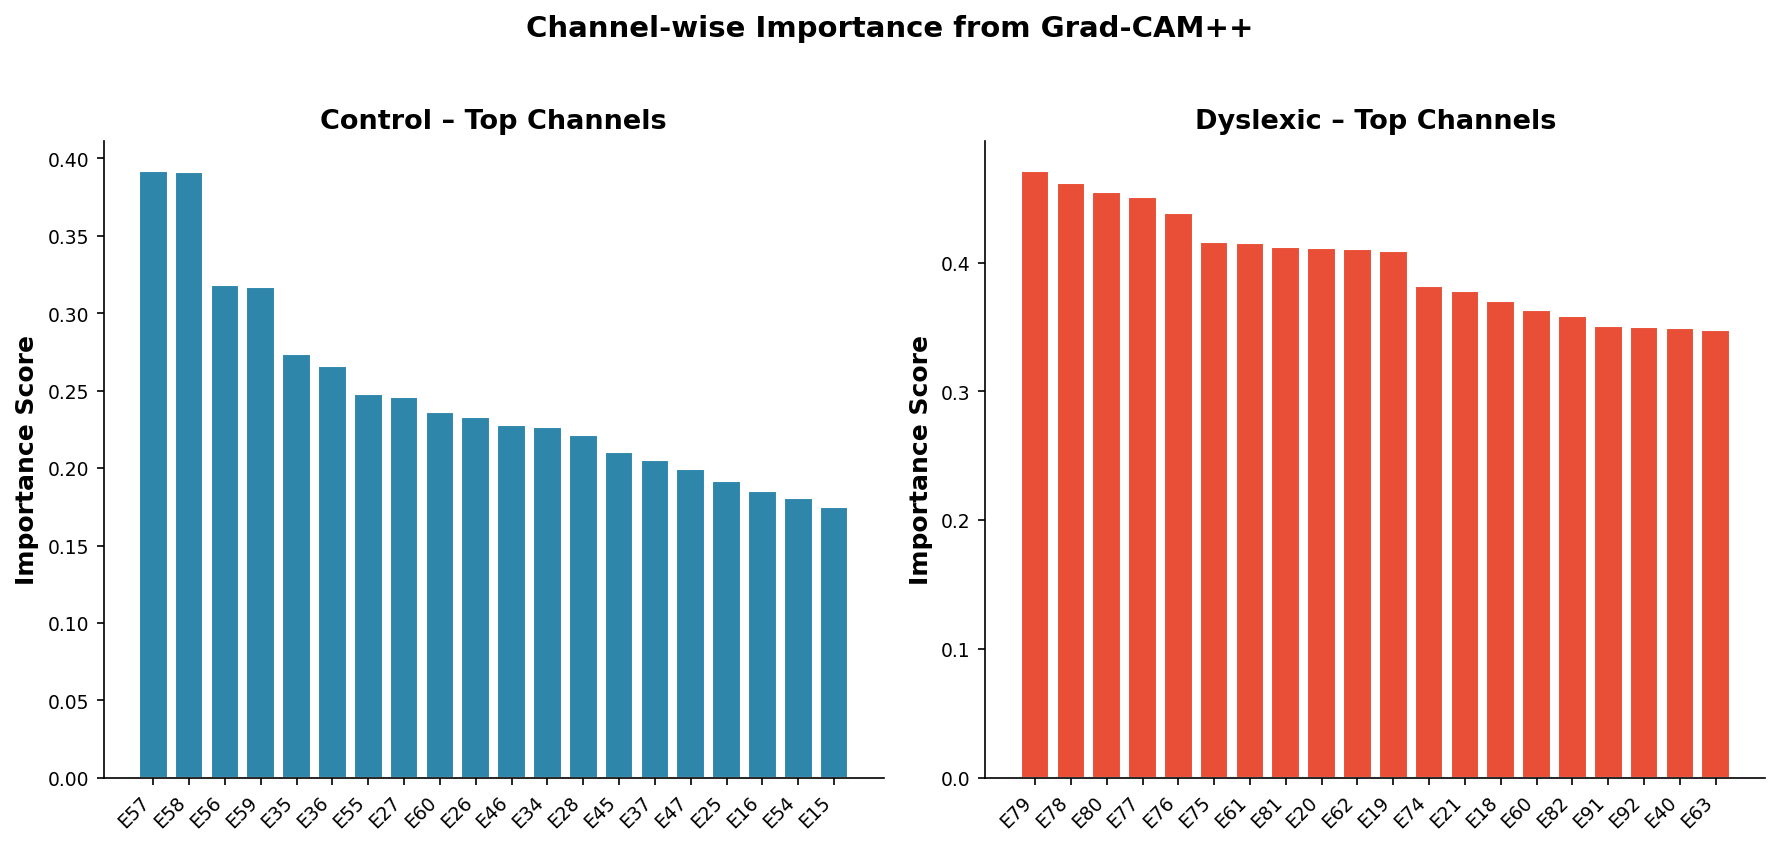

Generating qualitative overlays...


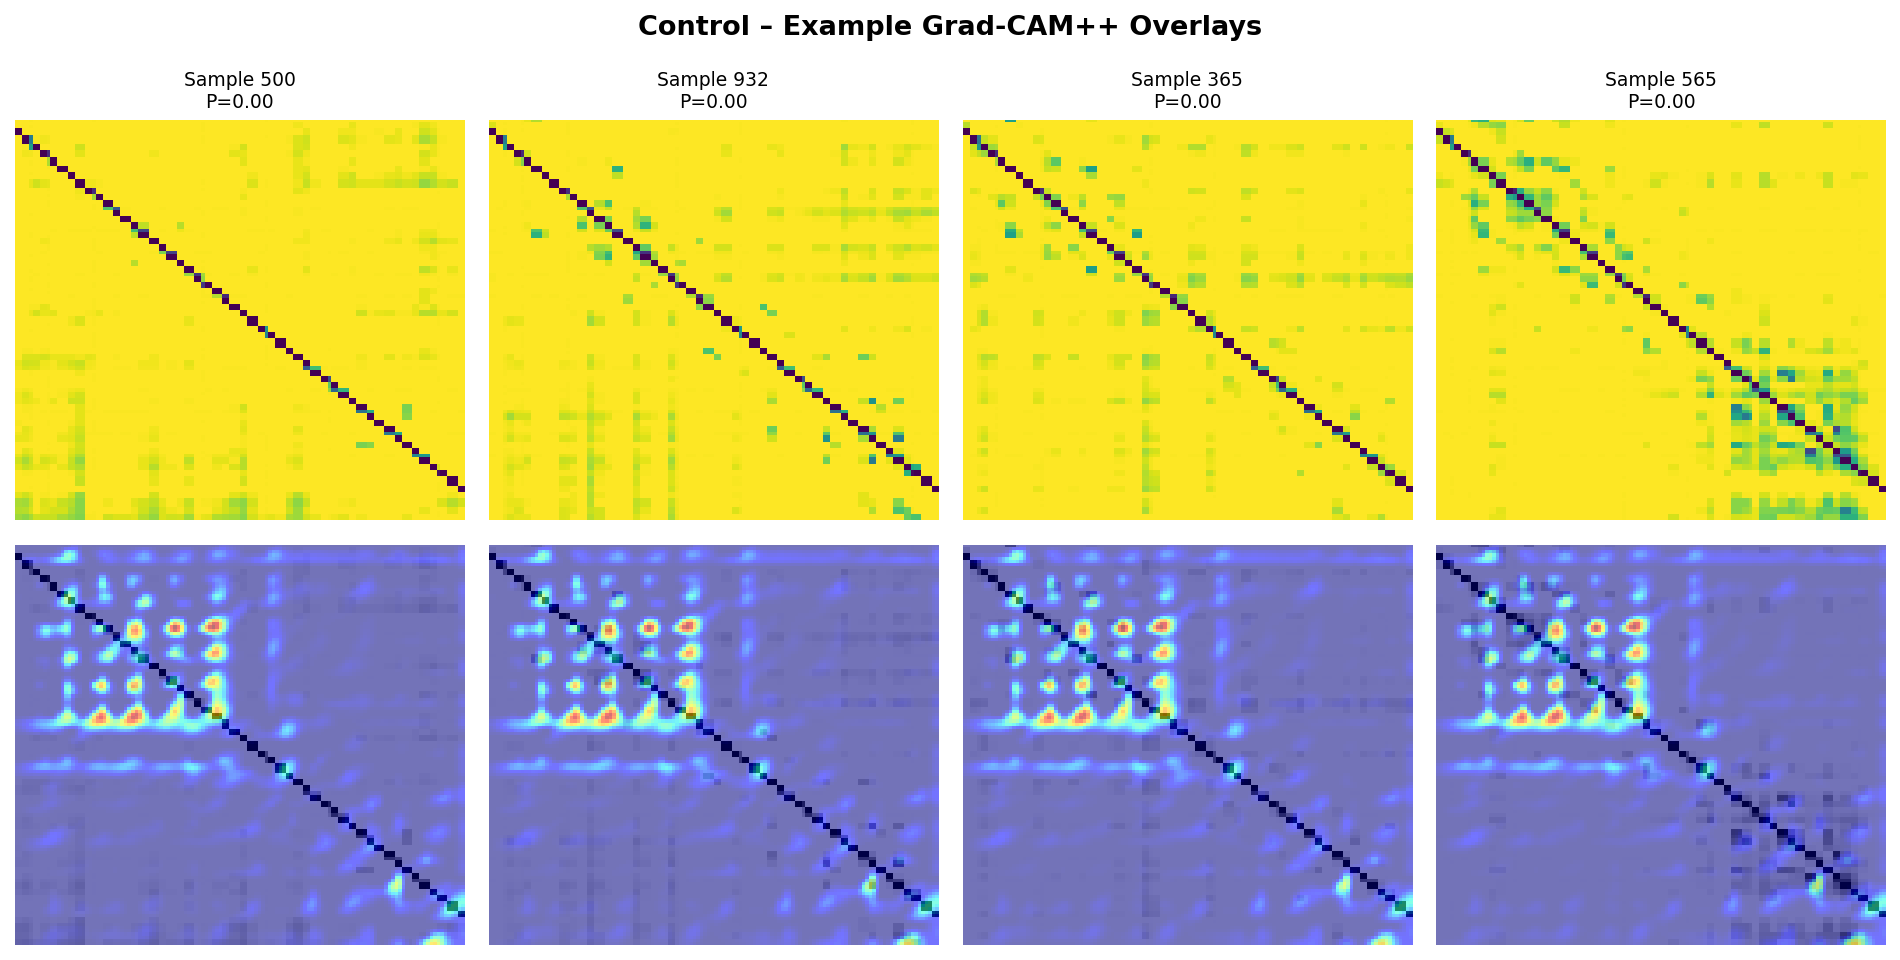

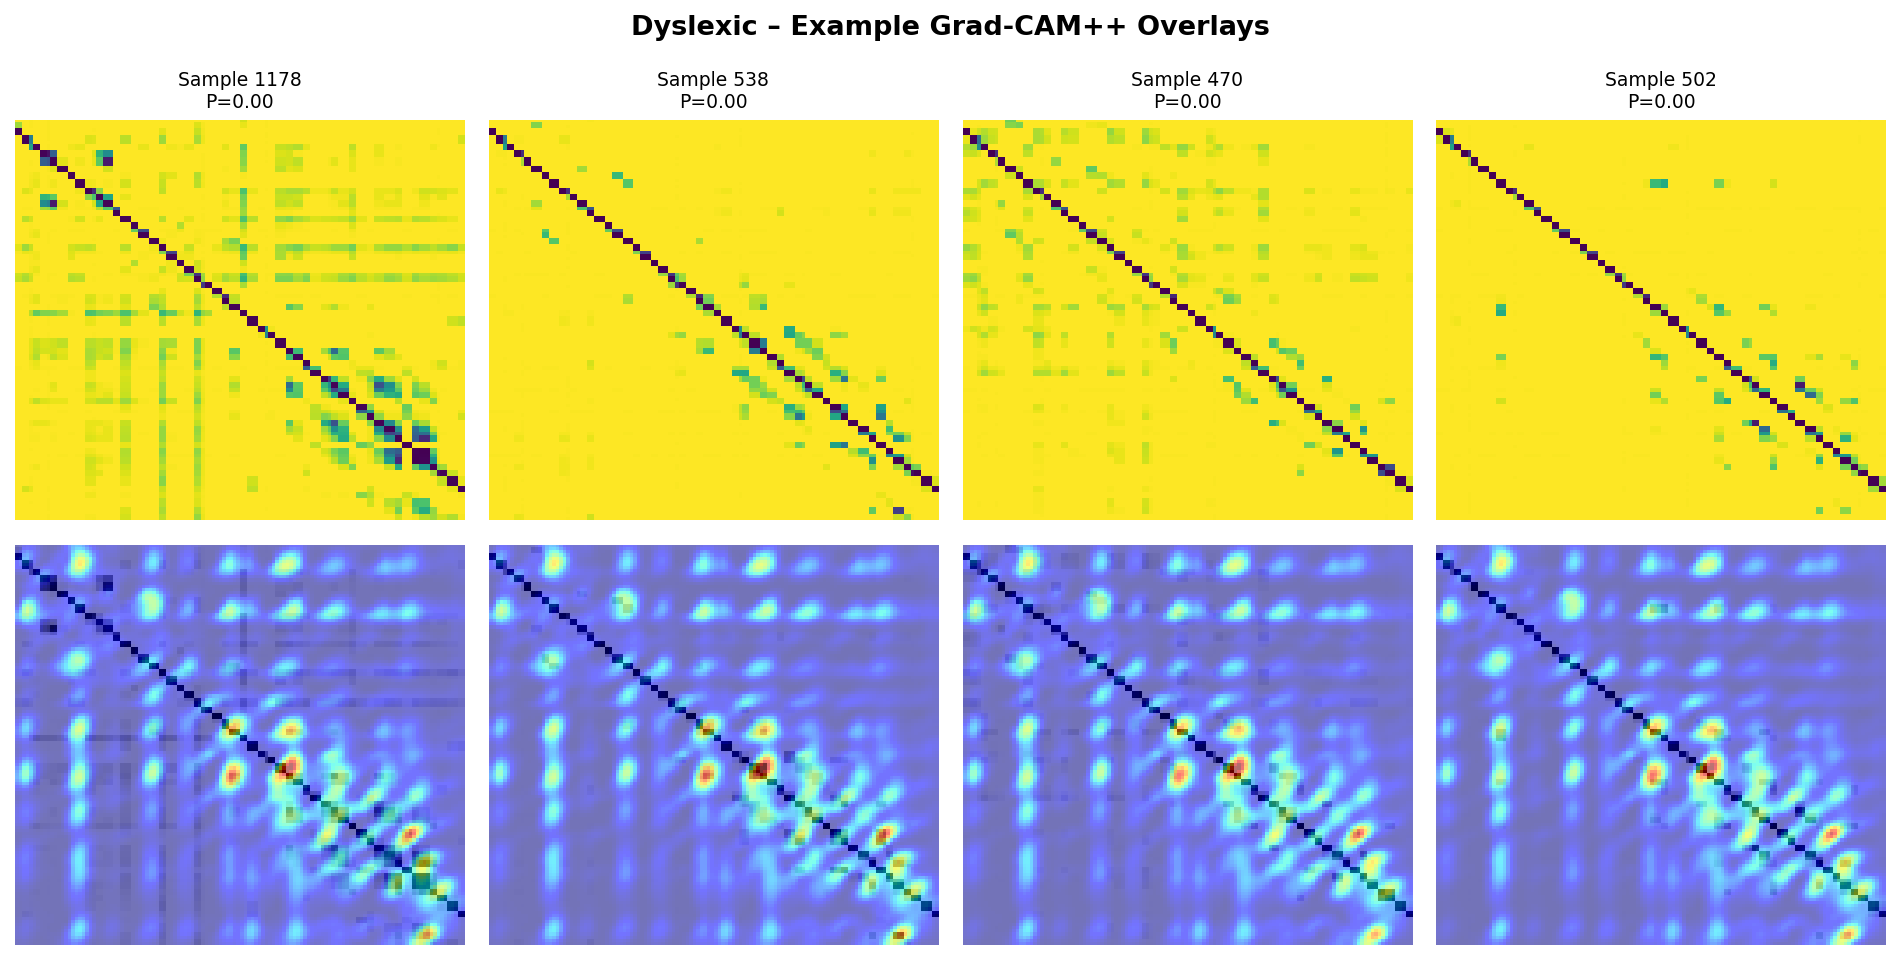


All advanced Grad-CAM++ figures saved (PNG 300 dpi + PDF).


In [5]:
# ============================================================
# ADVANCED GRAD-CAM++ VISUALIZATIONS (Q1 Journal Ready)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from collections import defaultdict
import pandas as pd

# ---------- Journal style ----------
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Custom colormaps
cmap_cam = "jet"
cmap_diff = LinearSegmentedColormap.from_list("diverging", 
                ["#2166ac", "#f7f7f7", "#b2182b"])

# ============================================================
# FIGURE A – Mean CAMs + Difference Map
# ============================================================
fig = plt.figure(figsize=(14, 5.2))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.28)

# Control
ax0 = fig.add_subplot(gs[0])
im0 = ax0.imshow(mean_cam_ctrl, cmap=cmap_cam, vmin=0, vmax=1,
                 extent=[1, N_CHANNELS, N_CHANNELS, 1])
ax0.set_title("Control\nMean Grad-CAM++", fontweight="bold")
ax0.set_xlabel("Channel")
ax0.set_ylabel("Channel")

# Dyslexic
ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(mean_cam_dys, cmap=cmap_cam, vmin=0, vmax=1,
                 extent=[1, N_CHANNELS, N_CHANNELS, 1])
ax1.set_title("Dyslexic\nMean Grad-CAM++", fontweight="bold")
ax1.set_xlabel("Channel")
ax1.set_ylabel("Channel")

# Difference (Dys – Control)
diff_cam = mean_cam_dys - mean_cam_ctrl
vmax = np.percentile(np.abs(diff_cam), 98)
ax2 = fig.add_subplot(gs[2])
im2 = ax2.imshow(diff_cam, cmap=cmap_diff, vmin=-vmax, vmax=vmax,
                 extent=[1, N_CHANNELS, N_CHANNELS, 1])
ax2.set_title("Difference\n(Dyslexic − Control)", fontweight="bold")
ax2.set_xlabel("Channel")
ax2.set_ylabel("Channel")

# Colorbar
cax = fig.add_subplot(gs[3])
plt.colorbar(im2, cax=cax, label="Δ Activation")

plt.suptitle("Grad-CAM++ Activation Maps", fontsize=14, fontweight="bold", y=1.02)
plt.savefig("figA_gradcam_heatmaps_diff.png", dpi=300)
plt.savefig("figA_gradcam_heatmaps_diff.pdf")
plt.show()

# ============================================================
# FIGURE B – Network Graphs of Top Channel Pairs
# ============================================================
def plot_connectivity_network(pairs, title, ax, color="#E94F37"):
    G = nx.Graph()
    for ci, cj, weight in pairs[:20]:          # top 20
        G.add_edge(ci, cj, weight=weight)

    # Circular layout looks clean for EEG channels
    pos = nx.circular_layout(G)
    
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1

    nx.draw_networkx_nodes(G, pos, node_size=380, node_color="#2E86AB",
                           edgecolors="white", linewidths=1.2, ax=ax)
    nx.draw_networkx_edges(G, pos, width=[w/max_w*3.5 for w in weights],
                           edge_color=color, alpha=0.75, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, font_color="white",
                            font_weight="bold", ax=ax)
    ax.set_title(title, fontweight="bold", pad=10)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plot_connectivity_network(ctrl_pairs, "Control – Top Pairs", axes[0], color="#2E86AB")
plot_connectivity_network(dys_pairs,  "Dyslexic – Top Pairs", axes[1], color="#E94F37")
plt.suptitle("Discriminative Functional Connectivity Patterns", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figB_channel_pair_networks.png", dpi=300)
plt.savefig("figB_channel_pair_networks.pdf")
plt.show()

# ============================================================
# FIGURE C – Ranked Unique Pairs (Horizontal bars)
# ============================================================
ctrl_unique = sorted(list(ctrl_set - dys_set), key=lambda x: x[0])
dys_unique  = sorted(list(dys_set - ctrl_set), key=lambda x: x[0])

# Get activation values for unique pairs
def get_unique_with_strength(unique_set, pairs):
    strength_dict = {(p[0], p[1]): p[2] for p in pairs}
    result = []
    for pair in unique_set:
        if pair in strength_dict:
            result.append((f"{pair[0]}–{pair[1]}", strength_dict[pair]))
    return sorted(result, key=lambda x: x[1], reverse=True)[:15]

ctrl_unique_str = get_unique_with_strength(ctrl_set - dys_set, ctrl_pairs)
dys_unique_str  = get_unique_with_strength(dys_set - ctrl_set, dys_pairs)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Control unique
names, vals = zip(*ctrl_unique_str) if ctrl_unique_str else ([], [])
axes[0].barh(names[::-1], vals[::-1], color="#2E86AB", edgecolor="white", height=0.7)
axes[0].set_xlabel("Mean Grad-CAM++ Activation", fontweight="bold")
axes[0].set_title("Unique to Control", fontweight="bold")
axes[0].set_xlim(0, max(vals)*1.15 if vals else 1)

# Dyslexic unique
names, vals = zip(*dys_unique_str) if dys_unique_str else ([], [])
axes[1].barh(names[::-1], vals[::-1], color="#E94F37", edgecolor="white", height=0.7)
axes[1].set_xlabel("Mean Grad-CAM++ Activation", fontweight="bold")
axes[1].set_title("Unique to Dyslexic", fontweight="bold")
axes[1].set_xlim(0, max(vals)*1.15 if vals else 1)

plt.suptitle("Class-Specific Discriminative Channel Pairs", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figC_unique_pairs_bars.png", dpi=300)
plt.savefig("figC_unique_pairs_bars.pdf")
plt.show()

# ============================================================
# FIGURE D – Channel Importance Ranking
# ============================================================
def compute_channel_importance(mean_cam, n_ch=N_CHANNELS):
    """Sum of activation for each channel (row + column)."""
    importance = np.zeros(n_ch)
    h, w = mean_cam.shape
    for i in range(n_ch):
        r_start = int(i * h / n_ch)
        r_end   = int((i+1) * h / n_ch)
        c_start = int(i * w / n_ch)
        c_end   = int((i+1) * w / n_ch)
        # row contribution + column contribution
        importance[i] = mean_cam[r_start:r_end, :].mean() + mean_cam[:, c_start:c_end].mean()
    return importance

imp_ctrl = compute_channel_importance(mean_cam_ctrl)
imp_dys  = compute_channel_importance(mean_cam_dys)

# Top 20 channels
top_k = 20
idx_ctrl = np.argsort(imp_ctrl)[-top_k:][::-1]
idx_dys  = np.argsort(imp_dys)[-top_k:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].bar(range(top_k), imp_ctrl[idx_ctrl], color="#2E86AB", edgecolor="white")
axes[0].set_xticks(range(top_k))
axes[0].set_xticklabels([f"E{i+1}" for i in idx_ctrl], rotation=45, ha="right")
axes[0].set_ylabel("Importance Score", fontweight="bold")
axes[0].set_title("Control – Top Channels", fontweight="bold")

axes[1].bar(range(top_k), imp_dys[idx_dys], color="#E94F37", edgecolor="white")
axes[1].set_xticks(range(top_k))
axes[1].set_xticklabels([f"E{i+1}" for i in idx_dys], rotation=45, ha="right")
axes[1].set_ylabel("Importance Score", fontweight="bold")
axes[1].set_title("Dyslexic – Top Channels", fontweight="bold")

plt.suptitle("Channel-wise Importance from Grad-CAM++", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figD_channel_importance.png", dpi=300)
plt.savefig("figD_channel_importance.pdf")
plt.show()

# ============================================================
# FIGURE E – Example Overlays (Qualitative)
# ============================================================
def show_overlay_examples(indices, mean_cam, class_name, n_show=4):
    fig, axes = plt.subplots(2, n_show, figsize=(3.2*n_show, 6.5))
    
    for i, idx in enumerate(indices[:n_show]):
        # Original connectivity matrix (take first channel or mean across RGB)
        img = X_test[idx].cpu().numpy()          # (3, H, W)
        img_gray = img.mean(axis=0)              # simple grayscale version
        
        # CAM for this sample
        img_tensor = X_test[idx].unsqueeze(0).float()
        cam, _, prob = gradcam_pp.generate(img_tensor) if 'gradcam_pp' in dir() else (mean_cam, 0, 0)
        cam_up = cv2.resize(cam, (img_cols, img_rows))
        
        # Row 0: original
        axes[0, i].imshow(img_gray, cmap="viridis", aspect="auto")
        axes[0, i].set_title(f"Sample {idx}\nP={prob:.2f}", fontsize=9)
        axes[0, i].axis("off")
        
        # Row 1: overlay
        axes[1, i].imshow(img_gray, cmap="gray", aspect="auto")
        axes[1, i].imshow(cam_up, cmap="jet", alpha=0.55, aspect="auto")
        axes[1, i].axis("off")
    
    axes[0, 0].set_ylabel("Original", fontweight="bold")
    axes[1, 0].set_ylabel("Grad-CAM++ Overlay", fontweight="bold")
    plt.suptitle(f"{class_name} – Example Grad-CAM++ Overlays", 
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"figE_overlays_{class_name.lower()}.png", dpi=300)
    plt.savefig(f"figE_overlays_{class_name.lower()}.pdf")
    plt.show()

# Re-create GradCAM object if hooks were removed
gradcam_pp = GradCAMPlusPlus(model, target_layer=model.conv5)

print("Generating qualitative overlays...")
show_overlay_examples(ctrl_indices, mean_cam_ctrl, "Control", n_show=4)
show_overlay_examples(dys_indices,  mean_cam_dys,  "Dyslexic", n_show=4)

gradcam_pp.remove_hooks()

print("\nAll advanced Grad-CAM++ figures saved (PNG 300 dpi + PDF).")